# Intensity Transformations and Neighbourhood Filtering

### EN3160 Image Processing and Machine Vision - Assignment 01
R. M. S. H. Ratnayake
(230548R)

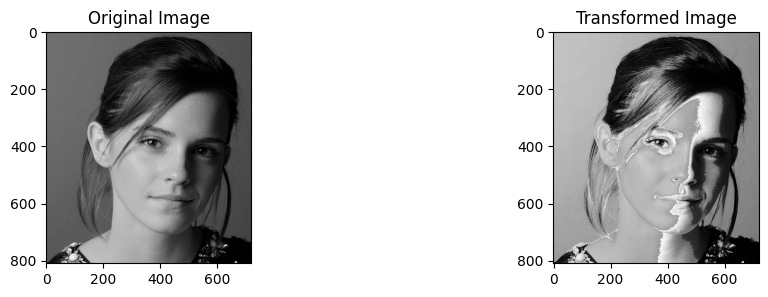

In [92]:
#Question 1
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
f = cv.imread("emma.jpg", cv.IMREAD_GRAYSCALE)
def intensity_transform(im, breakpoints):
    c = np.array(breakpoints)
    t1 = np.linspace(0, c[0, 1], c[0, 0] + 1).astype('uint8')  
    t2 = np.linspace(c[1, 1], c[2, 1], c[2, 0] - c[1, 0]).astype('uint8')
    t3 = np.linspace(c[3, 1], 255, 255 - c[3, 0]).astype('uint8')
    # Concatenate segments into a valid 256x1 Look-Up Table
    transform = np.concatenate((t1, t2, t3), axis=0).astype('uint8').reshape(256, 1)
    image_transformed = cv.LUT(im, transform)
    
    return image_transformed, transform
breakpoints = [(50, 50), (50, 100), (150, 255), (150, 150)]

# Apply transformation
img, tr = intensity_transform(f, breakpoints)

fig, ax = plt.subplots(1, 2, figsize=(12,3))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255);ax[0].set_title("Original Image")
ax[1].imshow(img, cmap='gray', vmin=0, vmax=255);ax[1].set_title("Transformed Image")
plt.show()


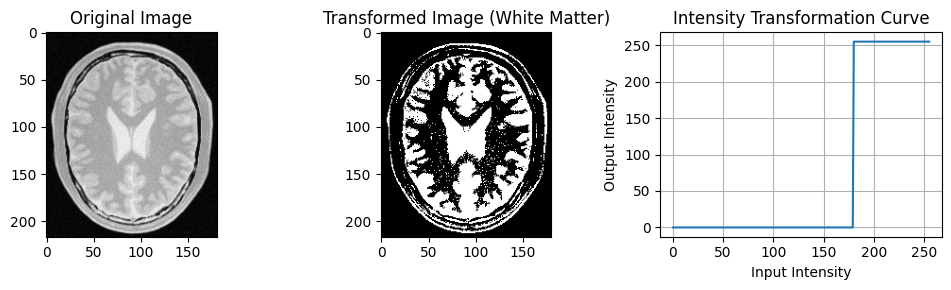

In [93]:
# Question 2

f = cv.imread("brain_proton_density_slice.png", cv.IMREAD_GRAYSCALE)
#part a).
t1= np.linspace(0, 0, 180, endpoint=False).astype("uint8")
t2= np.linspace(255, 255, 76).astype("uint8")
tr1= np.concatenate((t1, t2)).reshape(256, 1)

img_wm = cv.LUT(f, tr1)
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title("Original Image")
ax[1].imshow(img_wm, cmap='gray', vmin=0, vmax=255)
ax[1].set_title("Transformed Image (White Matter)")
ax[2].plot(tr1)
ax[2].set_title("Intensity Transformation Curve")
ax[2].set_xlabel("Input Intensity")
ax[2].set_ylabel("Output Intensity")
ax[2].grid(True)

plt.tight_layout()
plt.show()

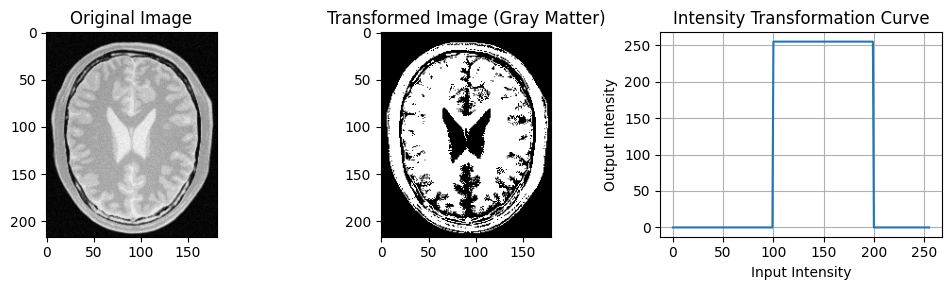

In [94]:
# Question 2
#part b).
gm_low   = np.linspace(0, 0, 100, endpoint=False).astype("uint8")
gm_boost = np.linspace(255, 255, 100, endpoint=False).astype("uint8")
gm_high  = np.linspace(0, 0, 56).astype("uint8")
tr_gm    = np.concatenate((gm_low, gm_boost, gm_high)).reshape(256, 1)

img_gm = cv.LUT(f, tr_gm)
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255); ax[0].set_title("Original Image")

ax[1].imshow(img_gm, cmap='gray', vmin=0, vmax=255);
ax[1].set_title("Transformed Image (Gray Matter)");ax[2].plot(tr_gm)
ax[2].set_title("Intensity Transformation Curve");ax[2].set_xlabel("Input Intensity");
ax[2].set_ylabel("Output Intensity");ax[2].grid(True)
plt.tight_layout()
plt.show()

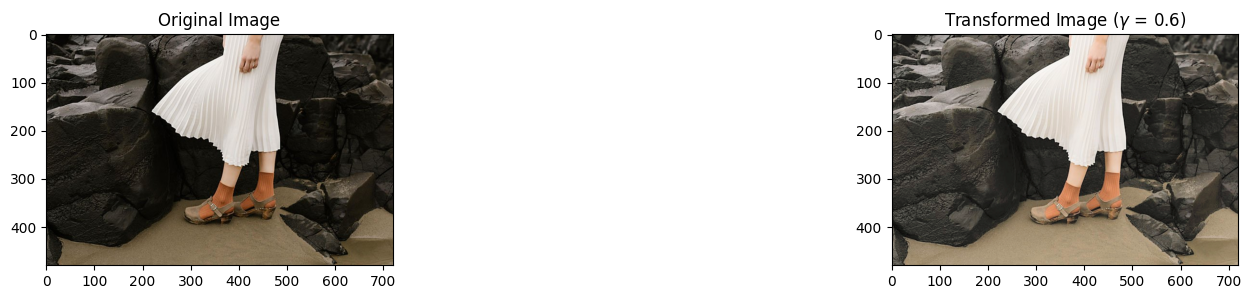

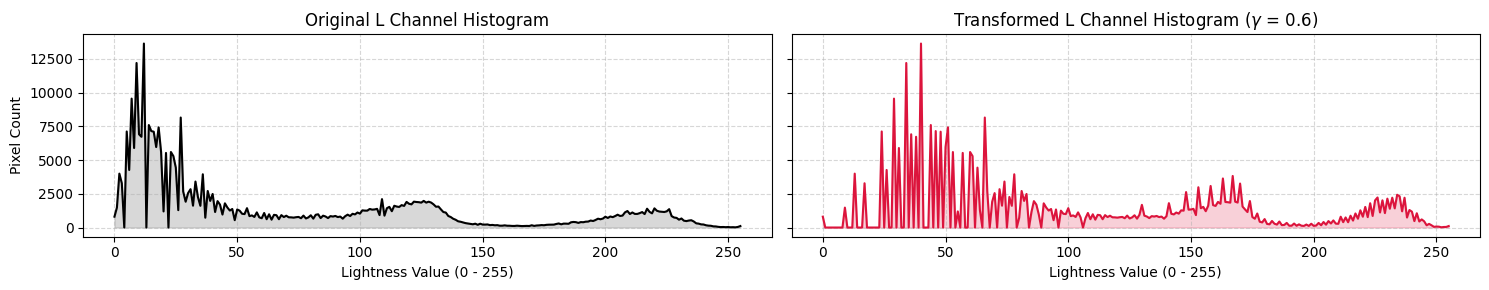

γ Value: 0.6


In [95]:
# Question 3
fig = cv.imread("highlights_and_shadows.jpg")
rgb_original = cv.cvtColor(fig, cv.COLOR_BGR2RGB)

img_lab = cv.cvtColor(fig, cv.COLOR_BGR2LAB)
L, a, b = cv.split(img_lab) #splitting to L*a*b planes

gamma= 0.6
tr = np.array([(((i/255)**gamma)*255) for i in range(256)], dtype=np.uint8)
L_new = cv.LUT(L, tr) #Transformation

modified= cv.merge([L_new, a, b])
bgr_result = cv.cvtColor(modified, cv.COLOR_LAB2BGR)
rgb_result = cv.cvtColor(bgr_result, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(20, 3))

ax[0].imshow(rgb_original)
ax[0].set_title("Original Image")
ax[1].imshow(rgb_result)
ax[1].set_title(f"Transformed Image ($\gamma$ = {gamma})")

# Plotting the histogram
hist_before = cv.calcHist([L], [0], None, [256], [0, 256])
hist_after = cv.calcHist([L_new], [0], None, [256], [0, 256])

fig, ax = plt.subplots(1, 2, figsize=(15, 3), sharey=True)
# Original L Channel Histogram
ax[0].plot(hist_before, color="black", linewidth=1.5)
ax[0].fill_between(range(256), hist_before.ravel(), color="gray", alpha=0.3)
ax[0].set_title("Original L Channel Histogram")
ax[0].set_xlabel("Lightness Value (0 - 255)")
ax[0].set_ylabel("Pixel Count")
ax[0].grid(True, linestyle="--", alpha=0.5)
# Transformed L Channel Histogram
ax[1].plot(hist_after, color="crimson", linewidth=1.5)
ax[1].fill_between(range(256), hist_after.ravel(), color="crimson", alpha=0.2)
ax[1].set_title(f"Transformed L Channel Histogram ($\gamma$ = {gamma})")
ax[1].set_xlabel("Lightness Value (0 - 255)")
ax[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()
print(f"γ Value: {gamma}")

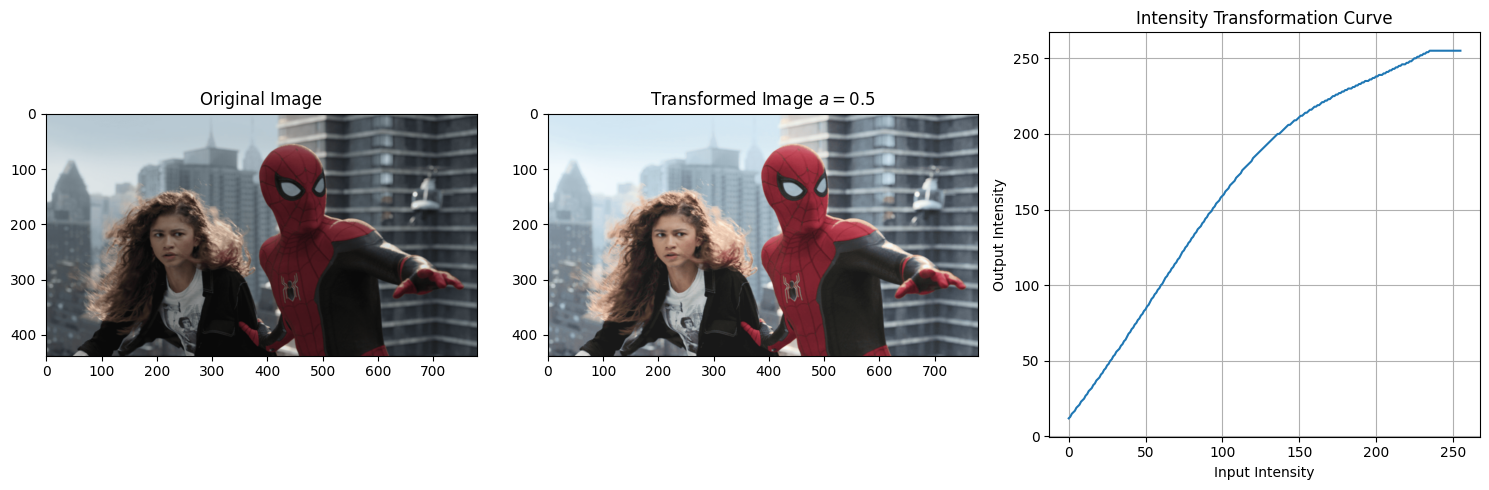

In [96]:
#Question 4
fig=  cv.imread("spider.png")
rgb_original= cv.cvtColor(fig, cv.COLOR_BGR2RGB)
img_hsv = cv.cvtColor(fig, cv.COLOR_BGR2HSV) # convert to hue, sturation, and value
h,s,v= cv.split(img_hsv)

a=0.5; sigma=70;
def f(x):
    return min(x+a*128*np.exp(-(x-128)**2/(2*sigma**2)),255)
tr = np.array([np.round(f(i)) for i in range(256)], dtype=np.uint8)
v_new=cv.LUT(v,tr)
modified= cv.merge([h,s,v_new])
bgr_result = cv.cvtColor(modified, cv.COLOR_HSV2BGR)
rgb_result = cv.cvtColor(bgr_result, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(rgb_original); ax[0].set_title("Original Image")
ax[1].imshow(rgb_result);ax[1].set_title(f"Transformed Image $a=${a}")
ax[2].plot(tr); 
ax[2].set_title("Intensity Transformation Curve");ax[2].set_xlabel("Input Intensity");
ax[2].set_ylabel("Output Intensity");ax[2].grid(True)
plt.tight_layout()
plt.show()

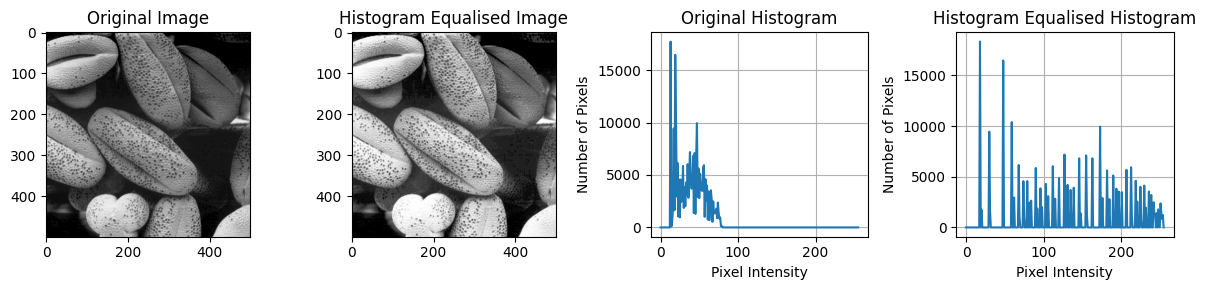

In [97]:
# Question 5
img = cv.imread("shells.tif", cv.IMREAD_GRAYSCALE)
def hist_equalisation(img):
    M, N = img.shape
    hist = cv.calcHist([img], [0], None, [256], [0, 256])
    cdf = hist.cumsum()
    tr = np.array([(255 * cdf[i]) / (M * N) for i in range(256)]).astype(np.uint8)
    return tr
tr = hist_equalisation(img)
new_img = cv.LUT(img, tr)
hist_original = cv.calcHist([img], [0], None, [256], [0, 256])
hist_new = cv.calcHist([new_img], [0], None, [256], [0, 256])

fig, ax = plt.subplots(1,4, figsize=(12, 3))
ax[0].imshow(img, cmap='gray'); ax[0].set_title("Original Image")
ax[1].imshow(new_img, cmap='gray');ax[1].set_title("Histogram Equalised Image")
ax[2].plot(hist_original);ax[2].set_title("Original Histogram");
ax[2].set_xlabel("Pixel Intensity");ax[2].set_ylabel("Number of Pixels")
ax[3].plot(hist_new);ax[3].set_title("Histogram Equalised Histogram");
ax[3].set_xlabel("Pixel Intensity");ax[3].set_ylabel("Number of Pixels")
ax[2].grid(True); ax[3].grid(True)
plt.tight_layout()
plt.show()

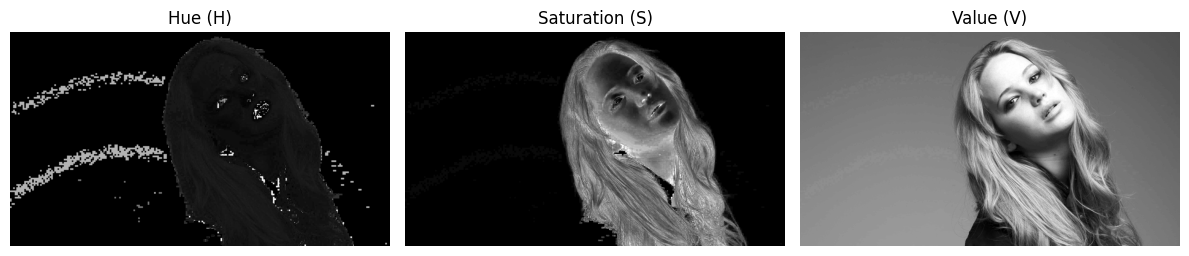

In [98]:
#Question 6
image=  cv.imread("jeniffer.jpg")
rgb_original= cv.cvtColor(image, cv.COLOR_BGR2RGB)
img_hsv = cv.cvtColor(image, cv.COLOR_BGR2HSV) # convert to hue, sturation, and value
h,s,v= cv.split(img_hsv)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(h, cmap='gray');ax[0].set_title("Hue (H)")
ax[1].imshow(s, cmap='gray');ax[1].set_title("Saturation (S)")
ax[2].imshow(v, cmap='gray');ax[2].set_title("Value (V)")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

The saturation plane can be selected to extract the mask

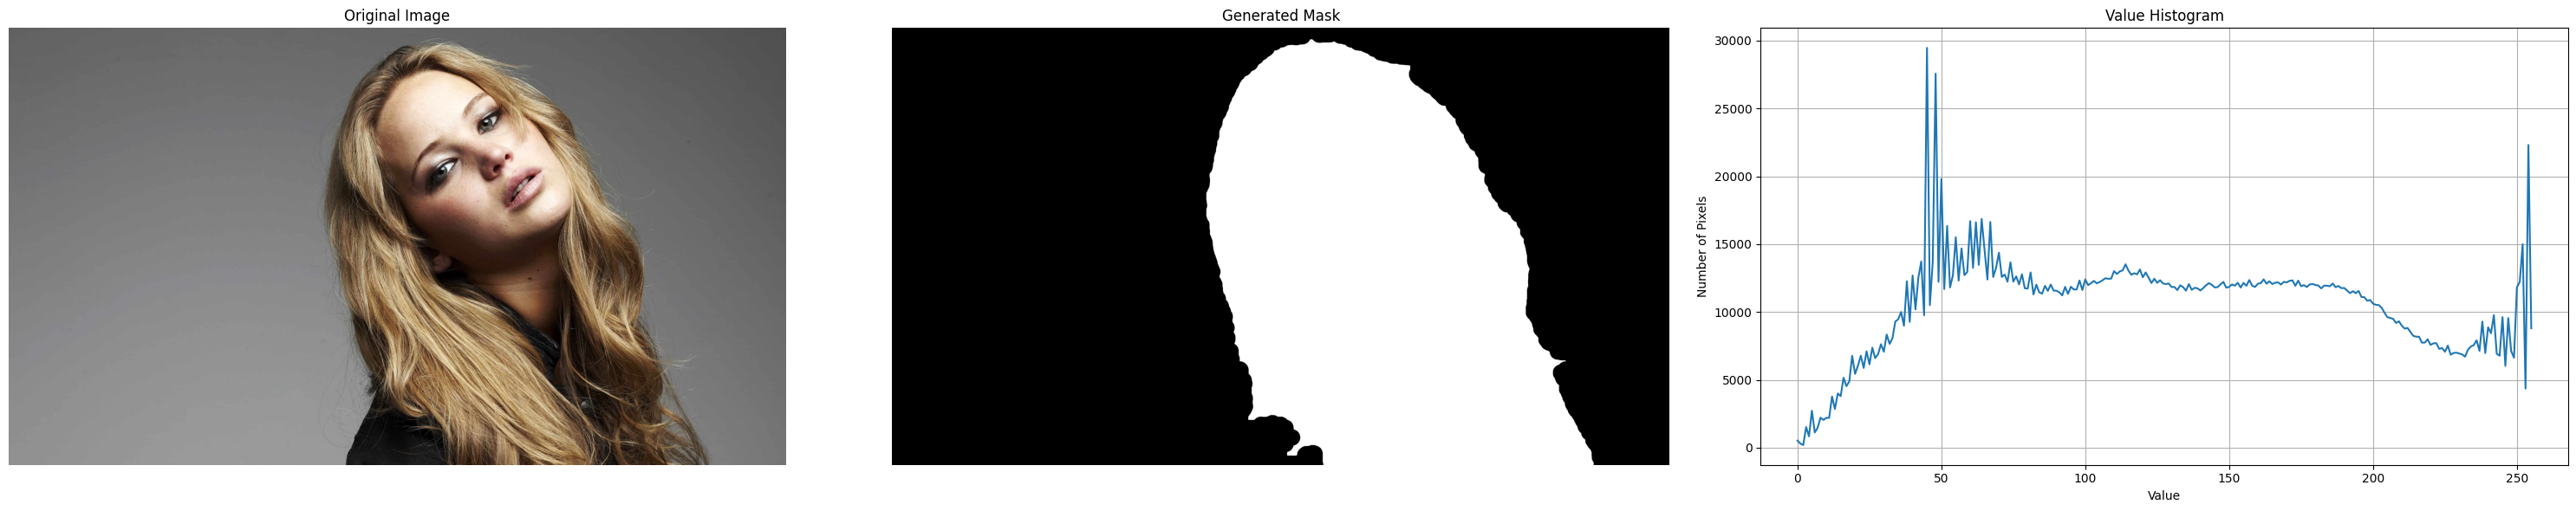

In [100]:
_, mask = cv.threshold(s, 15, 255, cv.THRESH_BINARY) # Create mask using the Saturation channel
# Apply morphological operations to reduce noise
foreground_mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, cv.getStructuringElement(cv.MORPH_ELLIPSE,(80, 80)))
foreground = cv.bitwise_and(image, image, mask=foreground_mask)
fgr = cv.cvtColor(foreground, cv.COLOR_BGR2HSV) # convert to hue, sturation, and value
h1,s1,value_plane=cv.split(fgr)

hist = cv.calcHist([value_plane], [0], mask, [256], [0, 256])
fig, ax = plt.subplots(1, 3, figsize=(30, 6))
ax[0].imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
ax[0].set_title("Original Image")
ax[1].imshow(foreground_mask, cmap="gray")
ax[1].set_title("Generated Mask")
ax[1].axis("off");ax[0].axis("off")
ax[2].plot(hist);ax[2].set_title("Value Histogram");ax[2].set_xlabel("Value");
ax[2].set_ylabel("Number of Pixels");ax[2].grid(True)
plt.tight_layout()
plt.show()

foreground_values = value_plane[foreground_mask > 0]
foreground_values_2d = foreground_values.reshape(-1, 1)
tr = hist_equalisation(foreground_values_2d)
value_equalized = value_plane.copy()
value_equalized[foreground_mask > 0] = tr[value_plane[foreground_mask > 0]] #Equalisation Step
modified = cv.merge([h1, s1, value_equalized])
equalized_image = cv.cvtColor(modified,cv.COLOR_HSV2BGR)

background_mask = cv.bitwise_not(foreground_mask)
background = cv.bitwise_and(image,image,mask=background_mask)
equalized_foreground = cv.bitwise_and(equalized_image,equalized_image,mask=foreground_mask)
result = cv.add(equalized_foreground,background)

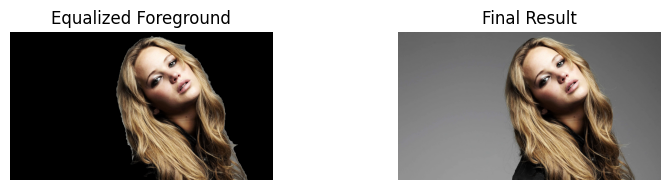

In [101]:
fig, ax = plt.subplots(1, 2, figsize=(8, 2))
# Equalized foreground
ax[0].imshow(cv.cvtColor(equalized_foreground, cv.COLOR_BGR2RGB))
ax[0].set_title("Equalized Foreground")
ax[1].axis("off");ax[0].axis("off")
# Final result
ax[1].imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
ax[1].set_title("Final Result")
ax[1].axis("off")
plt.tight_layout()
plt.show()

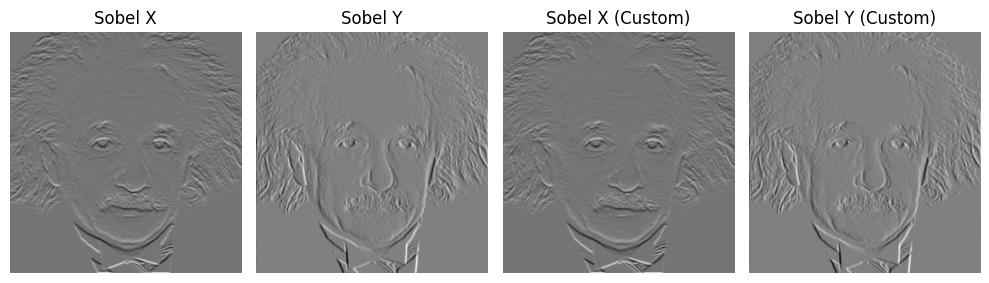

The defferences between Sobel X images : 0.0
The defferences between Sobel Y images : 0.0


In [102]:
#Question 7. Using built-in filter2d method
albert=cv.imread("einstein.png", cv.IMREAD_GRAYSCALE)
sobel_y=np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
sobel_x=np.array([[1,2,1],[0,0,0],[-1,-2,-1]])
im_x = cv.filter2D(albert, cv.CV_64F, sobel_x, borderType=cv.BORDER_CONSTANT)
im_y = cv.filter2D(albert, cv.CV_64F, sobel_y, borderType=cv.BORDER_CONSTANT)
#Using a custom Function
def convolve2d(image, kernel):
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape
    output = np.zeros((image_height, image_width),dtype=np.float32)
    pad_h = kernel_height // 2 ;pad_w = kernel_width // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)),mode='constant')    # Zero padding
 
    for i in range(image_height):
        for j in range(image_width):
            value = 0
            for m in range(kernel_height):
                for n in range(kernel_width):
                    value += (padded[i + m, j + n]*kernel[m, n])
            output[i, j] = value
    return output
im_x1=convolve2d(albert,sobel_x)
im_y1=convolve2d(albert, sobel_y)

fig, axs = plt.subplots(1, 4, figsize=(10, 3))
axs[0].imshow(im_x, cmap='gray');axs[0].set_title('Sobel X')
axs[1].imshow(im_y, cmap='gray');axs[1].set_title('Sobel Y')
axs[0].axis(False);axs[1].axis(False)
axs[2].imshow(im_x1, cmap='gray');axs[2].set_title('Sobel X (Custom)')
axs[3].imshow(im_y1, cmap='gray');axs[3].set_title('Sobel Y (Custom)')
axs[2].axis(False);axs[3].axis(False)
plt.tight_layout() ;plt.show()

print("The defferences between Sobel X images :",sum(sum(np.abs(im_x-im_x1))))
print("The defferences between Sobel Y images :",sum(sum(np.abs(im_y-im_y1))))

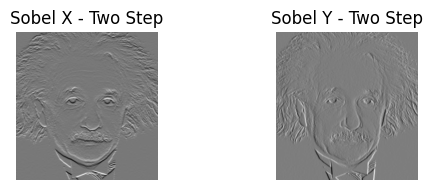

In [124]:
a=np.array([[1],[2],[1]])
b=np.array([1, 0, -1])
im_ya=cv.filter2D(albert, cv.CV_64F, a)
im_yb=cv.filter2D(im_ya, cv.CV_64F, b)
#Sobel X
a1 = np.array([1, 2, 1])
b1 = np.array([[1],[ 0],[-1]])
im_xa=cv.filter2D(albert, cv.CV_64F, a1)
im_xb=cv.filter2D(im_xa, cv.CV_64F, b1)
fig, axs = plt.subplots(1, 2, figsize=(6, 2))  
axs[1].imshow(im_yb, cmap='gray'); axs[1].set_title('Sobel Y - Two Step')
axs[0].imshow(im_xb, cmap='gray'); axs[0].set_title('Sobel X - Two Step')
axs[0].axis(False); axs[1].axis(False)
plt.tight_layout()
plt.show()

In [111]:
#Question 8
f1=cv.imread("images\im01small.png");f2=cv.imread("images\im02small.png");
f3=cv.imread("images\im03small.png");f4=cv.imread("images\im04small.jpg");
g1=cv.imread("images\im01.png");g2=cv.imread("images\im02.png");
g3=cv.imread("images\im03.png");g4=cv.imread("images\im04.jpg");
s = [f1, f2, f3, f4] ; g= [g1,g2,g3,g4]
def nearest_neighbour_interpolation(img, k):
    h, w = img.shape[:2]
    new_h = int(h * k)
    new_w = int(w * k)
    new_img = np.zeros((new_h, new_w, 3), dtype=img.dtype)
    for i in range(new_h):
        for j in range(new_w):
            x = i // k
            y = j // k
            new_img[i, j] = img[x, y]
    return new_img
near=[]; bilin=[]
for i in range(4):
    k=nearest_neighbour_interpolation(s[i],4)
    near.append(k)
def bilinear_interpolation(img, k):
    h, w = img.shape[:2]
    new_h = int(h * k)
    new_w = int(w * k)
    new_img = np.zeros((new_h, new_w,3), dtype=np.uint8)
    for i in range(new_h):
        for j in range(new_w):
            x = i / k
            y = j / k
            x_1 = int(x); y_1 = int(y)
            x_2 = min(x_1 + 1, h - 1); y_2 = min(y_1 + 1, w - 1)
            dx, dy= x - x_1, y - y_1
            val = ((1 - dx) * (1 - dy) * img[x_1, y_1]+ dx * (1 - dy) * img[x_2, y_1]+ (1 - dx) * dy * img[x_1, y_2] + dx * dy * img[x_2, y_2])
            new_img[i, j] = np.round(val)
    return new_img
for j in s:
    k=bilinear_interpolation(j,4)
    bilin.append(k)

In [112]:
def SSD(img1, img2):
    h = min(img1.shape[0], img2.shape[0])
    w = min(img1.shape[1], img2.shape[1])
    img1 = img1[:h, :w].astype(np.float64)
    img2 = img2[:h, :w].astype(np.float64)
    return np.sum((img1-img2)**2)
ssd_near = []
ssd_bilin = []

for i in range(4):
    ssd_near.append(SSD(near[i], g[i]))
    ssd_bilin.append(SSD(bilin[i], g[i]))

print("Nearest Neighbour SSD:", ssd_near)
print("Bilinear SSD:", ssd_bilin)

Nearest Neighbour SSD: [np.float64(847702500.0), np.float64(182795356.0), np.float64(709931859.0), np.float64(15363421.0)]
Bilinear SSD: [np.float64(1245096555.0), np.float64(339091600.0), np.float64(1030336103.0), np.float64(22194459.0)]


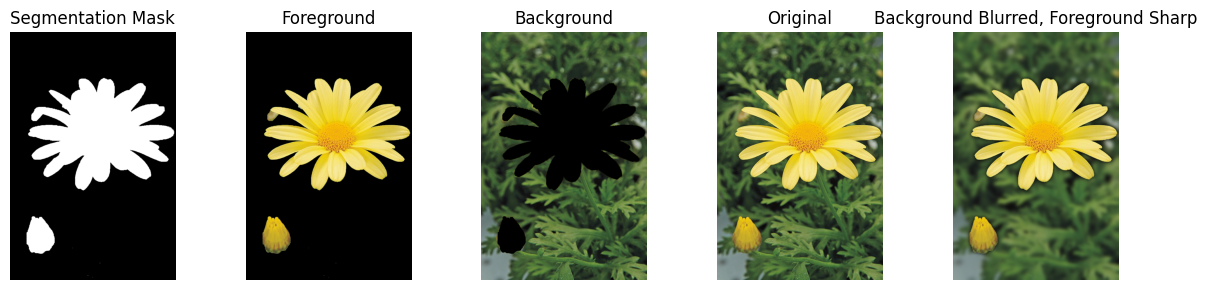

In [108]:
#Question 9
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread("daisy.jpg") # Load image
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

mask = np.zeros(img.shape[:2], np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

h, w = img.shape[:2]
rect = (int(0.1*w), int(0.1*h), int(0.9*w), int(0.9*h)) #Rough Area
cv.grabCut(img, mask, rect, bgdModel, fgdModel, 5, cv.GC_INIT_WITH_RECT)

mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')
foreground = img_rgb * mask2[:, :, np.newaxis] # Foreground image
background = img_rgb * (1 - mask2[:, :, np.newaxis]) # Background image (inverse mask)

blurred = cv.GaussianBlur(background, (35, 35), 0)   # kernel size controls blur strength
mask3 = mask2[:, :, np.newaxis]
result = img_rgb * mask3 + blurred * (1 - mask3)

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes[0].imshow(mask2, cmap='gray');axes[0].set_title("Segmentation Mask");axes[0].axis("off")
axes[1].imshow(foreground);axes[1].set_title("Foreground");axes[1].axis("off")
axes[2].imshow(background);axes[2].set_title("Background");axes[2].axis("off")
axes[3].imshow(img_rgb); axes[3].set_title("Original"); axes[3].axis("off")
axes[4].imshow(result); axes[4].set_title("Background Blurred, Foreground Sharp"); axes[4].axis("off")
plt.tight_layout()
plt.show()

#### The reason for dark, just beyond the edge of the flower 

When the background is bluring using a kernal, the pixels belonging to the foreground are replaced with zeros. Since the kernal averages the values, near the boarder are also mixing with the black pixels making the boarder darker

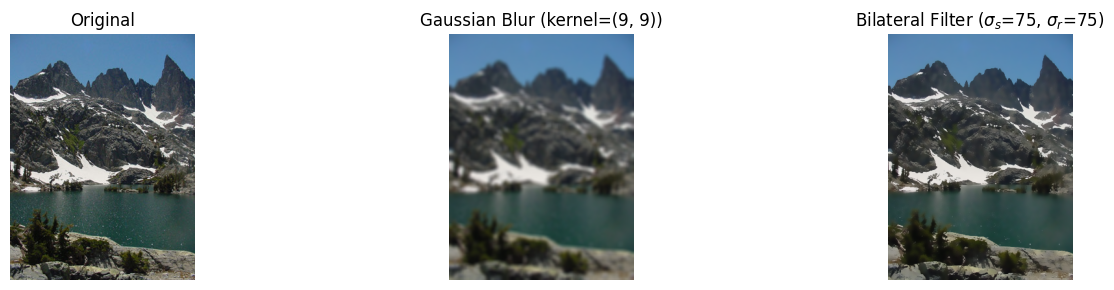

In [109]:
#Question 10
img = cv.imread("MinaretLake.jpg")
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

sigma_s = 75; sigma_r = 75
ksize=(9,9)
bilateral = cv.bilateralFilter(img_rgb, d=9, sigmaColor=sigma_r, sigmaSpace=sigma_s)
gaussian = cv.GaussianBlur(img_rgb, ksize, sigmaX=sigma_s/25) 

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
axes[0].imshow(img_rgb);axes[0].set_title("Original");axes[0].axis("off")
axes[1].imshow(gaussian);axes[1].set_title(f"Gaussian Blur (kernel={ksize})");axes[1].axis("off")
axes[2].imshow(bilateral);axes[2].set_title(f"Bilateral Filter ($\sigma_s$={sigma_s}, $\sigma_r$={sigma_r})");axes[2].axis("off")
plt.tight_layout()
plt.show()

MSE between two: 18.72445060018467


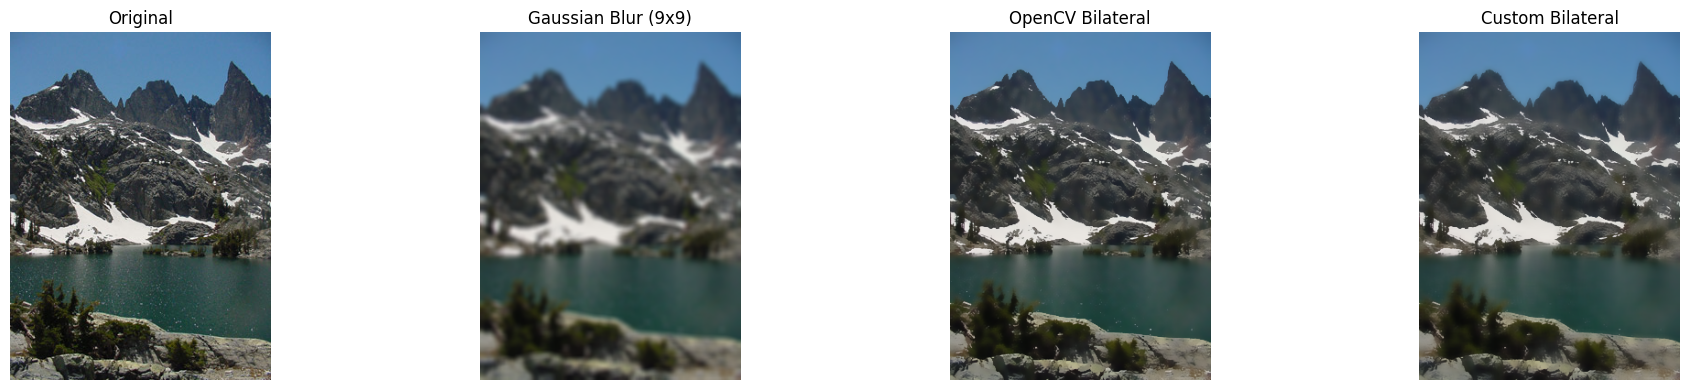

In [110]:
def my_bilateral_filter(img, d, sigma_s, sigma_r, eps=1e-8):
    img = np.asarray(img, dtype=np.float64)
    h, w, c = img.shape
    radius = d // 2
    padded = cv.copyMakeBorder(img, radius, radius, radius, radius, cv.BORDER_REFLECT)
    ax = np.arange(-radius, radius + 1)
    xx, yy = np.meshgrid(ax, ax)
    spatial_weight = np.exp(-(xx**2 + yy**2) / (2 * sigma_s**2))
    result_acc = np.zeros((h, w, c))
    weight_sum = np.zeros((h, w, 1))
    for i in range(d):
        for j in range(d):
            shifted = padded[i:i+h, j:j+w, :]
            diff = shifted - img
            range_dist_sq = np.sum(diff**2, axis=2, keepdims=True)
            exponent = np.clip(-range_dist_sq / (2 * sigma_r**2 + eps), -700, 0)
            range_weight = np.exp(exponent)
            weight = spatial_weight[i, j] * range_weight
            result_acc += weight * shifted
            weight_sum += weight
    output = result_acc / (weight_sum + eps)  # eps prevents divide-by-zero
    return output
my_bilateral = my_bilateral_filter(img_rgb, d, sigma_s, sigma_r)
my_bilateral_uint8 = np.clip(my_bilateral, 0, 255).astype(np.uint8)
print("MSE between two:", np.mean((my_bilateral_uint8-bilateral)**2))

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].imshow(img_rgb_uint8); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(gaussian); axes[1].set_title(f"Gaussian Blur ({d}x{d})"); axes[1].axis("off")
axes[2].imshow(bilateral); axes[2].set_title(f"OpenCV Bilateral"); axes[2].axis("off")
axes[3].imshow(my_bilateral_uint8); axes[3].set_title("Custom Bilateral"); axes[3].axis("off")
plt.tight_layout()
plt.show()